# Лекция 3 (1.3). Гауссовы целые

---

## Кольцо гауссовых целых

- $\mathbb{Z}[i] = \{a+bi : a,b\in\mathbb{Z}\}\subset\mathbb{C}$ ($i^2=-1$);
- $\mathbb{Z}[i]$ — коммутативное кольцо с $1$.
- Норма: $N(a+bi)=a^2+b^2=(a+bi)(a-bi)$;
- Мультипликативность: $N(zw)=N(z)N(w)$.
- Лемма: $N(z)=1 \Leftrightarrow z\in\{\pm1,\pm i\}$ (аналог в $\mathbb{Z}$: $|z|=1 \Leftrightarrow z\in\{\pm1\}$).
- $\{\pm1,\pm i\}$ — обратимые элементы $\mathbb{Z}[i]$ (единицы кольца).

In [4]:
# кольцо гауссовых целых и проверка факторизаций 5 и 13
ZZI = GaussianIntegers()

alpha_1 = ZZI(2+I)
alpha_2 = ZZI(2-I)
print(alpha_1*alpha_2)

beta_1 = ZZI(3+2*I)
beta_2 = ZZI(3-2*I)
print(beta_1*beta_2)

5
13


In [7]:
# 7 и 11 не представимы в виде a^2+b^2 (перебор), а значит не раскладываются как (a+bi)(a-bi)
def as_sum_two_squares(n):
    for a in range(0, isqrt(n)+1):
        b2 = n - a^2
        if b2 < 0:
            continue
        b = isqrt(b2)
        if b^2 == b2:
            return (a, b)
    return None

for n in [5, 7, 11, 13]:
    print(n, as_sum_two_squares(n))

5 (1, 2)
7 None
11 None
13 (2, 3)


In [8]:
ZZI = GaussianIntegers()
# норма и её мультипликативность: N(zw) = N(z)*N(w)
z = ZZI(3 + 5*I)
w = ZZI(-2 + 7*I)
print("N(z) =", z.norm(), " N(w) =", w.norm())
print("N(zw) =", (z*w).norm(), " N(z)*N(w) =", z.norm()*w.norm())

N(z) = 34  N(w) = 53
N(zw) = 1802  N(z)*N(w) = 1802


In [9]:
ZZI = GaussianIntegers()
# элементы с нормой 1 -- обратимые элементы (единицы) кольца
units = [ZZI(a + b*I) for a in range(-2, 3) for b in range(-2, 3) if ZZI(a + b*I).norm() == 1]
print(units)

# через готовые функции Sage
print(ZZI.number_field().unit_group().roots_of_unity())

[-1, -I, I, 1]
[I, -1, -I, 1]


---

## Арифметика гауссовых целых

- Теорема (деление с остатком): $\forall \alpha,\beta\in\mathbb{Z}[i],\, \beta\ne0\ \exists \delta,\gamma\in\mathbb{Z}[i]: \alpha=\beta \delta+\gamma,\ N(\gamma)<N(\beta)$;
- Евклидовы кольца $\rightleftharpoons$ кольца с делением с остатком (по некоторой норме); например, $\mathbb{Z}$, $\mathbb{Z}[i]$.
- Делимость в $\mathbb{Z}[i]$: $\beta\mid \alpha\rightleftharpoons \alpha=\beta \gamma$ для некоторого $\gamma\in\mathbb{Z}[i]$;
- $\pi\in\mathbb{Z}[i]\setminus\{\pm1,\pm i\}$ — простой $\rightleftharpoons$ $\pi=\alpha\beta \Rightarrow$ либо $\alpha$, либо $\beta\in\{\pm1,\pm i\}$;
- Теорема: Евклидовость $\Rightarrow$ Факториальность;
- Т.е. $\mathbb{Z}[i]$ — факториально: $\forall\alpha\in\mathbb{Z}[i]\,\alpha=\varepsilon \pi_1^{a_1}\dots\pi_k^{a_k}$, где $\varepsilon$ — единица, $\pi_i$ — простые;

In [10]:
ZZI = GaussianIntegers()

# деление с остатком: округляем комплексное частное a/b до ближайшего узла решётки Z[i]
def gauss_divmod(a, b):
    q_exact = a / b
    q = ZZI(round(q_exact.real()) + round(q_exact.imag())*I)
    r = a - b*q
    return q, r

alpha = ZZI(7 + I)
beta = ZZI(3 + 2*I)
delta, gamma = gauss_divmod(alpha, beta)
print(f"delta = {delta}, gamma = {gamma}")
print("alpha == beta*delta + gamma:", alpha == beta*delta + gamma)
print("N(gamma) < N(beta):", gamma.norm() < beta.norm())

delta = -I + 2, gamma = -1
alpha == beta*delta + gamma: True
N(gamma) < N(beta): True


In [11]:
ZZI = GaussianIntegers()
# факторизация 1+3i и проверка мультипликативности нормы
z = ZZI(1 + 3*I)
print(factor(z))
print("N(1+3i) =", z.norm())
print("N(1+i)*N(2+i) =", ZZI(1+I).norm() * ZZI(2+I).norm())

(-1) * (I - 1) * (2*I - 1)
N(1+3i) = 10
N(1+i)*N(2+i) = 10


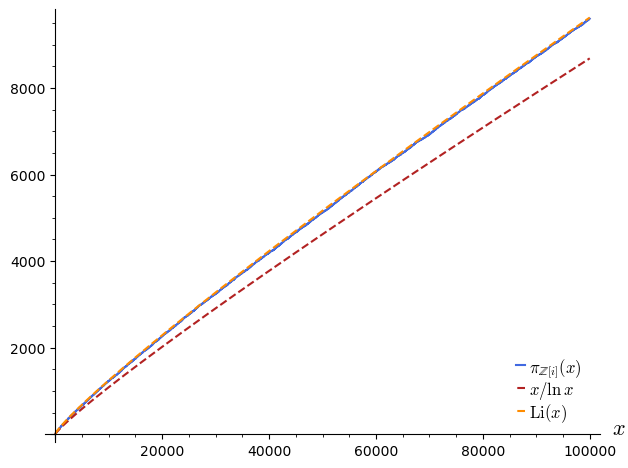

In [61]:
ZZI = GaussianIntegers()

def gaussian_primes_norms_upto(xmax):
    # представитель гауссова простого с точностью до единиц {1,i,-1,-i}: a>0, b>=0
    M = isqrt(xmax) + 1
    norms = []
    for a in range(1, M + 1):
        for b in range(0, M + 1):
            n = a^2 + b^2
            if n > xmax:
                continue
            if ZZI(a + b*I).is_prime():
                norms.append(n)
    norms.sort()
    return norms

xmax = 100000
norms = gaussian_primes_norms_upto(xmax)

xs = srange(10, xmax, 10)
from bisect import bisect_right
pi_vals = [(x, bisect_right(norms, x)) for x in xs]
approx_vals = [(x, x / log(x.n())) for x in xs]
li_vals = [(x, Li(x.n())) for x in xs]

p = plot_step_function(pi_vals, color='royalblue', thickness=1.5, legend_label='$\\pi_{\\mathbb{Z}[i]}(x)$')
p += line(approx_vals, color='firebrick', thickness=1.5, linestyle='--', legend_label='$x/\\ln x$')
p += line(li_vals, color='darkorange', thickness=1.5, linestyle='--', legend_label='$\\operatorname{Li}(x)$')
p.show(axes_labels=['$x$', ''], legend_loc='lower right', legend_font_size=12, legend_frameon=False)


---

## Теорема Эйлера-Ферма о сумме двух квадратов

- Простое $p\in\mathbb{Z}$ либо остаётся простым в $\mathbb{Z}[i]$, либо раскладывается на множители.
- Теорема: разложение $p\in\mathbb{Z}$ на простые в $\mathbb{Z}[i]$:
  - $p=2$: $2=-i(1+i)^2$ — «разветвляется»;
  - $p\equiv1\ (4)$: $p=\pi\bar\pi$, $\pi\ne\bar\pi$ — «распадается»;
  - $p\equiv3\ (4)$: $p$ — простое в $\mathbb{Z}[i]$ — «инертно».
- Если $p=\pi\bar\pi, \pi=a+bi$, то $N(\pi)=a^2+b^2=p$.
- Теорема: простое $p>2$ представимо как $p=a^2+b^2\ (a,b\in\mathbb{Z}) \Leftrightarrow p\equiv1\ (4)$.
- Теорема: $n\in\mathbb{Z}_{> 0}$ — сумма двух квадратов $\Leftrightarrow$ все простые $p\equiv3\ (4)$ входят в разложение $n$ в чётной степени.
- Пусть $r_2(n)$ — число представлений;
- Теорема (формула Якоби): $r_2(n) = 4\big(d_1(n)-d_3(n)\big)$, где $d_1(n), d_3(n)$ — число делителей $n$, сравнимых с $1$ и $3$ по модулю $4$.

In [13]:
ZZI = GaussianIntegers()
# факторизация простых p=2,5,7,11,13 в Z[i]: разветвление / распад / инертность
for p in [2, 5, 7, 11, 13]:
    print(p, "mod 4 =", p % 4, " -> ", factor(ZZI(p)))

2 mod 4 = 2  ->  (I) * (I - 1)^2
5 mod 4 = 1  ->  (-2*I - 1) * (2*I - 1)
7 mod 4 = 3  ->  7
11 mod 4 = 3  ->  11
13 mod 4 = 1  ->  (I) * (-2*I - 3) * (3*I + 2)


In [14]:
# представления p=a^2+b^2 перебором для простых p<=30:
def as_sum_two_squares(n):
    for a in range(0, isqrt(n)+1):
        b2 = n - a^2
        if b2 < 0:
            continue
        b = isqrt(b2)
        if b^2 == b2:
            return (a, b)
    return None

for p in primes(30):
    print(p, p % 4, as_sum_two_squares(p))

2 2 (1, 1)
3 3 None
5 1 (1, 2)
7 3 None
11 3 None
13 1 (2, 3)
17 1 (1, 4)
19 3 None
23 3 None
29 1 (2, 5)


In [15]:
# критерий: все простые p=3(4) входят в разложение n в чётной степени
def is_sum_two_squares(n):
    if n == 1:
        return True
    for p, e in factor(n):
        if p % 4 == 3 and e % 2 == 1:
            return False
    return True

for n in [1, 3, 10, 12, 21, 45]:
    print(n, factor(n), is_sum_two_squares(n))


1 1 True
3 3 False
10 2 * 5 True
12 2^2 * 3 False
21 3 * 7 False
45 3^2 * 5 True


In [16]:
# two_squares(n): встроенная функция Sage для разложения n = a^2 + b^2
# использует алгоритм Корначчи/факторизацию в Z[i] под капотом
for n in [5, 7, 13, 50]:
    try:
        a, b = two_squares(n)
        print(f"{n} = {a}^2 + {b}^2")
    except ValueError:
        print(f"{n}: нет представления в виде суммы двух квадратов")

5 = 1^2 + 2^2
7: нет представления в виде суммы двух квадратов
13 = 2^2 + 3^2
50 = 1^2 + 7^2


In [17]:
# r2(n): число представлений n=a^2+b^2 упорядоченными парами (a,b) in Z^2
def r2(n):
    count = 0
    for a in range(-isqrt(n), isqrt(n)+1):
        b2 = n - a^2
        if b2 < 0:
            continue
        b = isqrt(b2)
        if b^2 == b2:
            count += 1 if b == 0 else 2
    return count

# формула Якоби: r2(n) = 4*(d1(n) - d3(n))
def jacobi_r2(n):
    d1 = sum(1 for d in divisors(n) if d % 4 == 1)
    d3 = sum(1 for d in divisors(n) if d % 4 == 3)
    return 4*(d1 - d3)

for n in range(1,10):
    print(f"r2({n}) = {r2(n)},  формула Якоби = {jacobi_r2(n)}")

r2(1) = 4,  формула Якоби = 4
r2(2) = 4,  формула Якоби = 4
r2(3) = 0,  формула Якоби = 0
r2(4) = 4,  формула Якоби = 4
r2(5) = 8,  формула Якоби = 8
r2(6) = 0,  формула Якоби = 0
r2(7) = 0,  формула Якоби = 0
r2(8) = 4,  формула Якоби = 4
r2(9) = 4,  формула Якоби = 4


---

## Кольцо целых кватернионов

- $\mathbb{H}(\mathbb{Z})=\{\alpha=a+bi+cj+dk : a,b,c,d\in\mathbb{Z}\}$, где
- Представление $\alpha=a+bi+cj+dk$ однозначно;
- Умножение ассоциативно, $1$ — мультипликативная единица;
- $i^2=j^2=k^2=-1$;
- $ij=-ji=k$, $jk=-kj=i$, $ki=-ik=j$.
- $\mathbb{H}(\mathbb{Z})$ — некоммутативное кольцо;
- Сопряжение $\bar\alpha=a-bi-cj-dk$;
- Норма $N(\alpha)=\alpha\bar\alpha=a^2+b^2+c^2+d^2$.
- Мультипликативность: $N(\alpha\beta)=N(\alpha)N(\beta)$.

In [18]:
# алгебра кватернионов H(Q) с i^2=j^2=-1
# целые кватернионы -- элементы с целыми координатами
H = QuaternionAlgebra(QQ, -1, -1)
i, j, k = H.gens()

def q(a, b, c, d):
    return a + b*i + c*j + d*k

print(i*j, j*i, j*k, k*j, k*i, i*k)

k -k i -i j -j


In [19]:
# сопряжение и норма
alpha = q(1, 2, 3, 4)
print("i*j == j*i:", i*j == j*i)
print("alpha =", alpha, " conj(alpha) =", alpha.conjugate())
print("N(alpha) =", alpha.reduced_norm())

i*j == j*i: False
alpha = 1 + 2*i + 3*j + 4*k  conj(alpha) = 1 - 2*i - 3*j - 4*k
N(alpha) = 30


In [20]:
# мультипликативность нормы: N(alpha*beta) = N(alpha)*N(beta)
alpha = q(1, 2, 3, 4)
beta = q(0, 1, 1, 1)
print("N(alpha)*N(beta) =", alpha.reduced_norm()*beta.reduced_norm())
print("N(alpha*beta) =", (alpha*beta).reduced_norm())

N(alpha)*N(beta) = 90
N(alpha*beta) = 90


In [21]:
# целые (a,b,c,d) с нормой 1 (единицы)
units = [q(a,b,c,d) for a in range(-1,2) for b in range(-1,2)
                     for c in range(-1,2) for d in range(-1,2)
                     if q(a,b,c,d).reduced_norm() == 1]
print(units)

[-1, -i, -j, -k, k, j, i, 1]


In [22]:
 # целые кватернионы заданной нормы n (перебор)
def lipschitz_of_norm(n, bound):
    return [q(a,b,c,d) for a in range(-bound, bound+1) for b in range(-bound, bound+1)
                        for c in range(-bound, bound+1) for d in range(-bound, bound+1)
                        if a^2+b^2+c^2+d^2 == n]

# элементы нормы 2 -- неприводимые (2 простое в Z, нетривиальной факторизации нет)
elems2 = lipschitz_of_norm(2, 2)
print("число элементов нормы 2:", len(elems2))
print(elems2[:6], "...")

число элементов нормы 2: 24
[-1 - i, -1 - j, -1 - k, -1 + k, -1 + j, -1 + i] ...


---

## Арифметика целых кватернионов

- Лемма: $N(q)=1 \Leftrightarrow q\in\{\pm1,\pm i,\pm j,\pm k\}$;
- $\{\pm1,\pm i,\pm j,\pm k\}$ — обратимые элементы (единицы) $\mathbb{H}(\mathbb{Z})$.
- $\mathbb{H}(\mathbb{Z})$ — некоммутативно $\Rightarrow$ есть левая и правая делимость:
- $\beta\mid \alpha$ слева $\rightleftharpoons \alpha=\beta\gamma$, $\gamma\in\mathbb{H}(\mathbb{Z})$;
- $\beta\mid \alpha$ справа $\rightleftharpoons \alpha=\gamma\beta$, $\gamma\in\mathbb{H}(\mathbb{Z})$;
- Можно определить левый и правый НОД;
- $\pi\in\mathbb{H}(\mathbb{Z})\setminus\{\pm1,\pm i,\pm j,\pm k\}$ — неприводимый («простой») $\rightleftharpoons$ $\pi=\alpha\beta \Rightarrow$ либо $\alpha$, либо $\beta\in\{\pm1,\pm i,\pm j,\pm k\}$;
- Теорема: $\forall\alpha\in\mathbb{H}(\mathbb{Z})\,\alpha=\varepsilon \pi_1\dots\pi_k$, где $\varepsilon$ — единица, $\pi_i$ — простые;
- **!!** Ничего не сказано про однозначность, среди $\pi_i$ могут быть повторения.

In [23]:
# ищем все разложения alpha = pi1*pi2 с N(pi1)=N(pi2)=2 
# (иллюстрация неоднозначности факторизации)
alpha = q(1, 1, 1, 1)  # N(alpha) = 4
factorizations = [(p1, p2) for p1 in elems2 for p2 in elems2 if p1*p2 == alpha]
print("alpha =", alpha, " N(alpha) =", alpha.reduced_norm())
print("число найденных разложений alpha = pi1*pi2:", len(factorizations))
print(factorizations[:5])

alpha = 1 + i + j + k  N(alpha) = 4
число найденных разложений alpha = pi1*pi2: 24
[(-1 - i, -1 - j), (-1 - j, -1 - k), (-1 - k, -1 - i), (-1 + k, -j - k), (-1 + j, -i - j)]


---

## Теорема Лагранжа о сумме четырёх квадратов

- Теорема: если $p$ — нечетное простое в $\mathbb{Z}$, то $p$ раскладывается в $\mathbb{H}(\mathbb{Z})$: $p=\delta \bar\delta$;
- $\Rightarrow$ если $\delta=a+bi+cj+dk$, то $p=\delta \bar\delta = N(\delta) = a^2+b^2+c^2+d^2$;
- Теорема Лагранжа: каждое натуральное $n$ — сумма четырёх квадратов целых чисел.
- Формула Якоби для числа представлений: $r_4(n) = 8 \sum_{d\mid n,\, 4\nmid d} d$.

In [24]:
# 20 = 4*5 = N(1+i+j+k)*N(2+i), проверка через явное произведение кватернионов
alpha = q(1, 1, 1, 1)
beta = q(2, 1, 0, 0)
print("alpha =", alpha)
print("beta =", beta)
print("alpha*beta =", alpha*beta)
print("N(alpha*beta) =", (alpha*beta).reduced_norm(), " N(alpha)*N(beta) =", alpha.reduced_norm()*beta.reduced_norm())

alpha = 1 + i + j + k
beta = 2 + i
alpha*beta = 1 + 3*i + 3*j + k
N(alpha*beta) = 20  N(alpha)*N(beta) = 20


In [25]:
# r4(n): число представлений n=a^2+b^2+c^2+d^2 упорядоченными наборами (a,b,c,d) in Z^4
def r4(n):
    cnt = 0
    for a in range(-isqrt(n), isqrt(n)+1):
        r1 = n - a^2
        for b in range(-isqrt(r1), isqrt(r1)+1):
            r2 = r1 - b^2
            if r2 < 0:
                continue
            for c in range(-isqrt(r2), isqrt(r2)+1):
                d2 = r2 - c^2
                if d2 < 0:
                    continue
                d = isqrt(d2)
                if d^2 == d2:
                    cnt += 1 if d == 0 else 2
    return cnt

# формула Якоби: r4(n) = 8 * сумма делителей n, не кратных 4
def jacobi_r4(n):
    return 8*sum(d for d in divisors(n) if d % 4 != 0)

for n in [1, 2, 3, 4, 5, 20]:
    print(f"r4({n}) = {r4(n)},  формула Якоби = {jacobi_r4(n)}")

r4(1) = 8,  формула Якоби = 8
r4(2) = 24,  формула Якоби = 24
r4(3) = 32,  формула Якоби = 32
r4(4) = 24,  формула Якоби = 24
r4(5) = 48,  формула Якоби = 48
r4(20) = 144,  формула Якоби = 144


In [26]:
# встроенная функция Sage, аналог two_squares
for n in [4, 5, 20, 30]:
    print(n, "=", four_squares(n))

4 = (0, 0, 0, 2)
5 = (0, 0, 1, 2)
20 = (0, 0, 2, 4)
30 = (0, 1, 2, 5)


---

## Кольцо многочленов над полем

- $F[x]=\{a_0+a_1x+\dots+a_nx^n : n\ge0,\ a_i\in F\}$ — многочлены с коэффициентами из поля $F$.
- $F[x]$ — коммутативное кольцо с единицей без делителей нуля.
- Обратимые элементы: только ненулевые константы поля $F$ ($\deg f = 0$).
- Делимость: $g\mid f \rightleftharpoons f=gh$ для некоторого $h\in F[x]$.
- Степень: $\deg f = n$ в $f=a_0+\dots+a_nx^n$ ($a_n\ne0$).
- $\deg(fg)=\deg f+\deg g$ — аналог нормы.
- Теорема о делении с остатком: $\forall f,g\in F[x],\,g\ne0\ \exists! q,r: f=gq+r,\ \deg r<\deg g$.

In [27]:
# деление с остатком многочленов: quo_rem сразу даёт пару (q, r)
R.<x> = QQ[]
f = x^3 + 2*x + 1
g = x^2 + 1
q, r = f.quo_rem(g)
print(f"f = ({q})*g + ({r})")
print(f == g*q + r, r.degree() < g.degree())

f = (x)*g + (x + 1)
True True


In [28]:
# xgcd(f, g) -- тождество Безу для многочленов: d = s*f + t*g
R.<x> = QQ[]
f = x^3 - 1
g = x^2 - 1
d, s, t = xgcd(f, g)
print("gcd =", d, " s =", s, " t =", t)
print(d == s*f + t*g)

gcd = x - 1  s = 1  t = -x
True


In [29]:
# мультипликативная норма N(f) = p^deg(f) для поля F_p

p = 5
R.<x> = GF(p)[]

def N(f):
    return p^f.degree()

f = x^2 + 1
g = x^3 + x + 2
print("N(f) =", N(f), " N(g) =", N(g))
print("N(f*g) =", N(f*g), " N(f)*N(g) =", N(f)*N(g))

N(f) = 25  N(g) = 125
N(f*g) = 3125  N(f)*N(g) = 3125


---

## Неприводимые многочлены

- $f(x)\in F[x]$, $\deg f\ge1$ — неприводим $\rightleftharpoons$ $f(x)=g(x)h(x) \Rightarrow$ либо $\deg g=0$, либо $\deg h=0$ (т.е. один из множителей — обратимый элемент).
- $F[x]$ евклидово $\Rightarrow$ факториально: $\forall f\in F[x]\ f=c\cdot p_1^{a_1}\cdots p_k^{a_k}$, где $c\in F\setminus\{0\}$, $p_i=p_i(x)$ — неприводимые со старшим коэффициентом $1$.

In [30]:
# неприводимость, пример 1
Rq.<x> = QQ[]
f_q = x^2 + 1
print("x^2+1 над QQ:", f_q.is_irreducible())

R2.<x> = GF(2)[]
f_2 = x^2 + 1
print("x^2+1 над F_2:", f_2.is_irreducible(), " =", f_2.factor())

R3.<x> = GF(3)[]
f_3 = x^2 + 1
print("x^2+1 над F_3:", f_3.is_irreducible())

x^2+1 над QQ: True
x^2+1 над F_2: False  = (x + 1)^2
x^2+1 над F_3: True


In [31]:
# неприводимость, пример 2
Rq.<x> = QQ[]
h_q = x^2 - 2
print("x^2-2 над QQ:", h_q.is_irreducible())

R3.<x> = GF(3)[]
h_3 = x^2 - 2
print("x^2-2 над F_3:", h_3.is_irreducible())

R7.<x> = GF(7)[]
h_7 = x^2 - 2
print("x^2-2 над F_7:", h_7.is_irreducible(), " =", h_7.factor())

x^2-2 над QQ: True
x^2-2 над F_3: True
x^2-2 над F_7: False  = (x + 3) * (x + 4)


In [32]:
# разложение на множители
Rq.<x> = QQ[]
print("x^4-1 над QQ:", (x^4 - 1).factor())

R2.<x> = GF(2)[]
print("x^4-1 над F_2:", (x^4 - 1).factor())

x^4-1 над QQ: (x - 1) * (x + 1) * (x^2 + 1)
x^4-1 над F_2: (x + 1)^4


---

## От сравнений к идеалам и факторкольцам

- В $\mathbb{Z}$: $a\equiv b\pmod{n} \Leftrightarrow n\mid(a-b)$
- $\Leftrightarrow a-b\in(n)$, где $(n)=\{kn : k\in\mathbb{Z}\}$.
- Идеал $I\subset R$ ($R$ — коммутативно) $\leftrightharpoons$ $\forall a,b\in I\ a+b\in I$, $\forall a\in I\, r\in R\ ra\in I$;
- Т.е. идеал — подгруппа по $+$, замкнутая относительно умножения на любой элемент: $RI\subset I$.
- $a\sim_I b \leftrightharpoons a-b\in I$ — отношение эквивалентности;
- Классы эквивалентности: $\bar a=a+I=\{a+x : x\in I\}$;
- Факторкольцо $R/I = \{\bar a\}$ c операциями $(a+I)+(b+I)=(a+b)+I$ и $(a+I)(b+I)=ab+I$;
- Пример: $(n)=\{kn : k\in\mathbb{Z}\}$ — идеал, $\mathbb{Z}/n\mathbb{Z}=\mathbb{Z}/(n)$;
- Обозначение: $(a)=\{ra : r\in R\}$ — главный идеал.

In [33]:
# Z/nZ единым способом через QuotientRing: R/I для R=ZZ, I=(n)
n = 7
Q = QuotientRing(ZZ, ZZ.ideal(n))
print(Q)
print("10 mod 7 =", Q(10), " равен 3?", Q(10) == Q(3))

Quotient of Integer Ring by the ideal (7)
10 mod 7 = 3  равен 3? True


In [34]:
Rr.<x> = QQ[]
# F[x]/(x^2+1) той же конструкцией QuotientRing -- элемент xbar играет роль i
Q = QuotientRing(Rr, Rr.ideal(x^2 + 1))
xbar = Q.gen(0)
print("xbar^2 =", xbar^2)

xbar^2 = -1


In [ ]:
# иллюстрация изоморфизма R[x]/(x^2+1) = C: сравниваем умножение (a+b*xbar) с (a+bi)
a, b, cc, d = 2, 3, -1, 5
u = a + b*xbar
v = cc + d*xbar
print("(a+b*xbar)*(c+d*xbar) =", u*v)

z1 = CC(a, b); z2 = CC(cc, d)
print("(a+bi)*(c+di) =", z1*z2)

(a+b*xbar)*(c+d*xbar) = 7*xbar - 17
(a+bi)*(c+di) = -17.0000000000000 + 7.00000000000000*I


---

## Конечные поля $\mathbb{F}_{p^n}$ как факторкольца

- Теорема: $F[x]/(f(x))$ — поле $\Leftrightarrow f$ неприводим;
- (Аналогия: $\mathbb{F}_p=\mathbb{Z}/p\mathbb{Z}$ — поле $\Leftrightarrow p$ — простое).
- Для $F=\mathbb{F}_p=\mathbb{Z}/p\mathbb{Z}$: если $f$ — неприводим (над $\mathbb{F}_p$), то $\mathbb{F}_p[x]/(f(x))$ — поле;
- Число элементов $|\mathbb{F}_p[x]/(f(x))|=p^n$, $n=\deg(f)$;
- Теорема: $\forall$ конечного поля $\mathbb{F}$ из $q=|\mathbb{F}|$ элементов $\exists$ простое число $p$ и неприводимый $f\in\mathbb{F}_p[x]$ степени $\deg(f)=n$ такие, что $q=p^n$ и $\mathbb{F}_q\cong\mathbb{F}_p[x]/(f(x))$.

In [36]:
R.<x> = GF(2)[]
f = x^2 + x + 1
print("f неприводим над F_2:", f.is_irreducible())

# явное построение F_2[x]/(f)
F4_manual = QuotientRing(R, R.ideal(f))
w = F4_manual.gen(0)
print("w^2 =", w^2, " (= w+1 ?)", w^2 == w + 1)
print("w^3 =", w^3)

f неприводим над F_2: True
w^2 = xbar + 1  (= w+1 ?) True
w^3 = 1


In [37]:
# сравнение с встроенным GF(2^2): под капотом та же конструкция F_p[x]/(f)
F4 = GF(4, 'a')
print(F4)
print("минимальный многочлен образующей:", F4.modulus())
a = F4.gen()
print("a^2 =", a^2, " a^3 =", a^3)

Finite Field in a of size 2^2
минимальный многочлен образующей: x^2 + x + 1
a^2 = a + 1  a^3 = 1


In [38]:
# таблица умножения F4^*
F4 = GF(4, 'a')
a = F4.gen() # мультипликативная группы циклическая
nonzero = [x for x in F4 if x != 0]
print(nonzero)
for u in nonzero:
    print([u*v for v in nonzero])

[a, a + 1, 1]
[a + 1, 1, a]
[1, a, a + 1]
[a, a + 1, 1]


In [62]:
# встроенная функция
print(F4.multiplication_table(names='elements'))

    *      0     1     a a + 1
     +------------------------
    0|     0     0     0     0
    1|     0     1     a a + 1
    a|     0     a a + 1     1
a + 1|     0 a + 1     1     a



---

## Факторкольца гауссовых и кватернионов

- Теорема: $\mathbb{Z}[i]/(\pi)$ — конечное кольцо; если $\pi$ простой, то это поле, и $|\mathbb{Z}[i]/(\pi)|=N(\pi)$, при этом:
  - $p=2$: $\mathbb{Z}[i]/(1+i)\cong\mathbb{F}_2$;
  - $p\equiv1\ (4)$: $p=\pi\bar\pi$, $N(\pi)=p$, $\mathbb{Z}[i]/(\pi)\cong\mathbb{F}_p$;
  - $p\equiv3\ (4)$: $p$ остаётся простым, $N(p)=p^2$, $\mathbb{Z}[i]/(p)\cong\mathbb{F}_{p^2}$.
- Кольцо $\mathbb{H}(\mathbb{Z})$ (кватернионы Липшица) не евклидово;
- Кватернионы Гурвица:
$$\mathcal H := \mathbb{H}(\mathbb{Z}) \cup \Big(\mathbb{H}(\mathbb{Z}) + \tfrac12(1+i+j+k)\Big);$$
- Арифметика $\mathcal H$ — кандидат на лабораторную работу.

In [40]:
# Z[i]/(pi) как поле вычетов идеала: сравнение с F_5
# в отличие отпримеров выше удобнее работать через квадратичное поле (поле частных)
K.<i> = QuadraticField(-1)
P = K.ideal(2 + i)
RF = P.residue_field()
print(P, " N(P) =", P.norm())
print(RF, " |RF| =", RF.cardinality())

Fractional ideal (i + 2)  N(P) = 5
Residue field of Fractional ideal (i + 2)  |RF| = 5


In [41]:
# три примера: p=2 (разветвление), p=5=1(4) (распад), p=7=3(4) (инертность)
K.<i> = QuadraticField(-1)
for p, gen in [(2, 1+i), (5, 2+i), (7, 7)]:
    RF = K.ideal(gen).residue_field()
    print(f"p={p}: Z[i]/({gen}) имеет мощность {RF.cardinality()}")

p=2: Z[i]/(i + 1) имеет мощность 2
p=5: Z[i]/(i + 2) имеет мощность 5
p=7: Z[i]/(7) имеет мощность 49


In [42]:
# пример фаторизации H(Z)/pH(Z)
p = 5
Fp = GF(p)

# умножение кватернионов Гамильтона по координатам (a,b,c,d) <-> a+bi+cj+dk
def hmul(u, v):
    a1,b1,c1,d1 = u
    a2,b2,c2,d2 = v
    return (a1*a2 - b1*b2 - c1*c2 - d1*d2,
            a1*b2 + b1*a2 + c1*d2 - d1*c2,
            a1*c2 - b1*d2 + c1*a2 + d1*b2,
            a1*d2 + b1*c2 - c1*b2 + d1*a2)

# H(Z)/pH(Z): координаты по F_p, всего p^4 элементов
elems = [(a,b,c,d) for a in Fp for b in Fp for c in Fp for d in Fp]
print("|H(Z)/pH(Z)| =", len(elems), " = p^4:", len(elems) == p^4)

# некоммутативность сохраняется и после редукции по модулю p
Ie, Je = (Fp(0),Fp(1),Fp(0),Fp(0)), (Fp(0),Fp(0),Fp(1),Fp(0))
print("i*j =", hmul(Ie,Je), " j*i =", hmul(Je,Ie))

|H(Z)/pH(Z)| = 625  = p^4: True
i*j = (0, 0, 0, 1)  j*i = (0, 0, 0, 4)


In [43]:
# в H(Z)/pH(Z) есть делители нуля
# (1+2i) имеет норму 1+4=5=0 mod 5, поэтому (1+2i)*conj(1+2i) = N(1+2i) = 0
alpha0 = (Fp(1), Fp(2), Fp(0), Fp(0))
alpha0_conj = (Fp(1), -Fp(2), Fp(0), Fp(0))
print("alpha0 =", alpha0, " conj(alpha0) =", alpha0_conj)
print("alpha0 * conj(alpha0) =", hmul(alpha0, alpha0_conj))

alpha0 = (1, 2, 0, 0)  conj(alpha0) = (1, 3, 0, 0)
alpha0 * conj(alpha0) = (0, 0, 0, 0)


In [44]:
# рациональные кватернионы
H = QuaternionAlgebra(QQ, -1, -1)
i, j, k = H.gens()
def q(a, b, c, d):
    return a + b*i + c*j + d*k

# кольцо целых Гурвица H = H.maximal_order()
# в Sage строит как максимальный порядок алгебры (-1,-1)
Hur = H.maximal_order()
print(Hur)
print("дискриминант:", Hur.discriminant())

Order of Quaternion Algebra (-1, -1) with base ring Rational Field with basis (1/2 + 1/2*i + 1/2*j + 1/2*k, i, j, k)
дискриминант: 2


In [45]:
# H(Z) содержится в Hur, и в Hur есть полуцелые кватернионы вида H(Z) + 1/2(1+i+j+k)
w = q(1,1,1,1)
half = q(1/2, 1/2, 1/2, 1/2)
print("1+i+j+k in Hur:", w in Hur, " N =", w.reduced_norm())
print("1/2(1+i+j+k) in Hur:", half in Hur, " N =", half.reduced_norm())
print("1/2(1+i+j-k) in Hur:", q(1/2,1/2,1/2,-1/2) in Hur)

1+i+j+k in Hur: True  N = 4
1/2(1+i+j+k) in Hur: True  N = 1
1/2(1+i+j-k) in Hur: True


In [46]:
p = 5
Fp = GF(p)

# ищем a,b in F_p с a^2+b^2=-1 (существует для любого нечётного p)
a, b = next((a,b) for a in Fp for b in Fp if a^2 + b^2 == -1)
print("a, b =", a, b)

Im = matrix(Fp, [[a, b], [b, -a]])
Jm = matrix(Fp, [[0, 1], [-1, 0]])
E = identity_matrix(Fp, 2)
Km = Im * Jm

# проверяем базовые соотношения H: I^2=J^2=K^2=-E, IJ=-JI
print("I^2 == -E:", Im^2 == -E, " J^2 == -E:", Jm^2 == -E, " K^2 == -E:", Km^2 == -E)
print("IJ == -JI:", Im*Jm == -Jm*Im)

a, b = 0 2
I^2 == -E: True  J^2 == -E: True  K^2 == -E: True
IJ == -JI: True


In [47]:
# явный изоморфизм Hur/pHur -> M_2(F_p): a0*E + a1*I + a2*J + a3*K
def phi(a0, a1, a2, a3):
    return Fp(a0)*E + Fp(a1)*Im + Fp(a2)*Jm + Fp(a3)*Km

# delta=2+i имеет норму p=5 -- образ должен быть вырожденной (необратимой) матрицей
M_delta = phi(2, 1, 0, 0)
print("phi(2+i) =", M_delta, " det =", M_delta.det())

# элемент нормы, взаимно простой с p, даёт обратимую матрицу
M_unit = phi(1, 1, 0, 0)
print("phi(1+i) =", M_unit, " det =", M_unit.det())

phi(2+i) = [2 2]
[2 2]  det = 0
phi(1+i) = [1 2]
[2 1]  det = 2


---

## Когда однозначность разложения нарушается

- $\mathbb{Z}[\sqrt{-5}]=\{a+b\sqrt{-5}\}$ — кольцо; делимость, арифметика, $\dots$
- Арифметика кольца связана с вопросом: Какие целые числа представимы в виде $a^2+5b^2=N(a+b\sqrt{-5})$?
- Обозначение: $(a,b)=\{ra+sb: r,s\in R\}$ — идеал

In [48]:
# s = sqrt(-5), R = Z[sqrt(-5)] -- кольцо целых поля QuadraticField(-5)
K.<s> = QuadraticField(-5)  

# два разложения 6 на "неприводимые" множители
print("2*3 =", K(2)*K(3))
print("(1+s)*(1-s) =", (1+s)*(1-s))
print("совпадают:", K(2)*K(3) == (1+s)*(1-s))

2*3 = 6
(1+s)*(1-s) = 6
совпадают: True


In [49]:
# нормы множителей: N(2)=4, N(3)=9, N(1+-s)=6.
# неприводимый элемент не может расколоться на два "меньших" множителя,
# то есть на пару элементов норм >1, произведение которых даёт нужную норму;
# для этого достаточно отсутствия элементов норм 2 и 3 (нетривиальных делителей)

def has_norm(n, bound=50):
    # ищем a,b in Z c a^2+5b^2=n (норма элемента a+b*sqrt(-5))
    for a in range(-bound, bound+1):
        for b in range(-bound, bound+1):
            if a^2 + 5*b^2 == n:
                return (a, b)
    return None

for n in [2, 3, 4, 6, 9]:
    print(n, has_norm(n))

2 None
3 None
4 (-2, 0)
6 (-1, -1)
9 (-3, 0)


In [50]:
K.<s> = QuadraticField(-5)
# идеал (a,b) = {ra+sb : r,s in R} -- порождённый двумя элементами; K.ideal(...) строит его по образующим
p2  = K.ideal(2, 1+s)
p3  = K.ideal(3, 1+s)
p3b = K.ideal(3, 1-s)

# простой идеал: p != R и ab in p => a in p или b in p (аналог простого числа, но для идеалов)
print("p2 простой:", p2.is_prime(), " p3 простой:", p3.is_prime(), " p3bar простой:", p3b.is_prime())

p2 простой: True  p3 простой: True  p3bar простой: True


In [51]:
K.<s> = QuadraticField(-5)
p2  = K.ideal(2, 1+s)
p3  = K.ideal(3, 1+s)
p3b = K.ideal(3, 1-s)

# оба разложения 6 -- это одно и то же разложение идеала (6) в произведение простых идеалов
print("p2^2 == (2):", p2^2 == K.ideal(2))
print("p3*p3bar == (3):", p3*p3b == K.ideal(3))
print("p2*p3 == (1+s):", p2*p3 == K.ideal(1+s))
print("p2*p3bar == (1-s):", p2*p3b == K.ideal(1-s))
print("(6) =", K.ideal(6).factor())

p2^2 == (2): True
p3*p3bar == (3): True
p2*p3 == (1+s): True
p2*p3bar == (1-s): True
(6) = (Fractional ideal (2, s + 1))^2 * (Fractional ideal (3, s + 1)) * (Fractional ideal (3, s + 2))


---

## Квадратичные поля: когда факториальность есть

- Теорема: кольцо факториально $\Leftrightarrow$ каждый идеал в нём главный (кольцо главных идеалов).
- «Кольца целых алгебраических чисел в полях $\mathbb{Q}(\sqrt d)$» ($d$ — свободное от квадратов целое) обобщают $\mathbb{Z}[i]$ ($d=-1$):
- Это кольца вида
  - $R_d=\mathbb{Z}[\sqrt d]=\{a+b\sqrt d: a,b\in\mathbb{Z}\}$, если $d\equiv2,3\ (4)$,
  - $R_d=\mathbb{Z}\big[\tfrac{1+\sqrt d}2\big]=\{a+b\tfrac{1+\sqrt d}2: a,b\in\mathbb{Z}\}$, если $d\equiv1\ (4)$;
- Связаны с решением уравнений вида $x^2+dy^2=k$ ($x,y,k\in\mathbb{Z}$);
- Вопрос: для каких $d<0$ кольцо $R_d$ факториально?
- Теорема (Хегнер, 1952; Бейкер--Старк, 1966--67): ровно для 9 значений $d=-1,-2,-3,-7,-11,-19,-43,-67,-163$;
- Гипотеза Гаусса: есть бесконечно много $d>0$ для которых $R_d$ факториально.

In [52]:
# группа классов идеалов Cl(K) := (дробные идеалы R_d) / (главные дробные идеалы);
# число классов h(K) = |Cl(K)| -- конечная группа для колец целых числовых полей.
# h(K)=1  <=>  каждый идеал главный  <=>  R_d факториально (по теореме со слайда)
heegner = [-1, -2, -3, -7, -11, -19, -43, -67, -163]
for d in heegner:
    K = QuadraticField(d)
    print(d, "h =", K.class_number())

-1 h = 1
-2 h = 1
-3 h = 1
-7 h = 1
-11 h = 1
-19 h = 1
-43 h = 1
-67 h = 1
-163 h = 1


In [53]:
# для сравнения -- d, не входящие в список Хегнера: число классов > 1, т.е. R_d НЕ факториально
# в частности d=-5 -- это ровно кольцо Z[sqrt(-5)] из предыдущего слайда, h=2
for d in [-5, -6, -10, -14, -17, -23]:
    K = QuadraticField(d)
    print(d, "h =", K.class_number())

-5 h = 2
-6 h = 2
-10 h = 2
-14 h = 4
-17 h = 4
-23 h = 3


In [54]:
# вещественный случай (d>0): гипотеза Гаусса до сих пор открыта,
# но примеров с h=1 среди малых d действительно много
for d in [2, 3, 5, 6, 7, 10, 13, 15, 79]:
    K = QuadraticField(d)
    print(d, "h =", K.class_number())

2 h = 1
3 h = 1
5 h = 1
6 h = 1
7 h = 1
10 h = 2
13 h = 1
15 h = 2
79 h = 3


---

## Кольца и поля

- Множество и две согласованные операции $+$, $\times$ (дистрибутивность).
- Кольцо $R$: коммутативная группа по $+$; ассоциативность $\times$; примеры:
  - $\mathbb{Z}$, $\mathbb{Z}/n\mathbb{Z}$, $F[x]$, $\mathbb{Z}[i]$ — коммутативные;
  - $\mathbb{Z}/n\mathbb{Z}$ может иметь делители нуля;
  - $\mathbb{H}(\mathbb{Z})$ — некоммутативное.
- $R^*$ — группа единиц кольца $R$ (обратимые по $\times$); примеры:
  - $\mathbb{Z}^*=\{\pm1\}$; $\mathbb{Z}[i]^*=\{\pm1,\pm i\}$; $\mathbb{H}(\mathbb{Z})^* = \{\pm1,\pm i,\pm j,\pm k\}$;
  - $F[x]^*=F^*$;
  - $|(\mathbb{Z}/n\mathbb{Z})^*|=\varphi(n)$.
- Поле $F$: коммутативное кольцо с $1\ne0$, $F^*$ — группа по $\times$; примеры:
  - $\mathbb{Q},\mathbb{R},\mathbb{C}$ — бесконечные поля;
  - $\mathbb{F}_p=\mathbb{Z}/p\mathbb{Z}, \mathbb{F}_{p^n}=\mathbb{F}_p[x]/(f(x))$ — конечные;
  - $\mathbb{Q}(x) = \left\{\frac{f(x)}{g(x)}: f,g\in\mathbb{Q}[x], g\neq 0\right\}$ — поле рациональных функций;
  - Если $R$ — кольцо без делителей 0, то можно построить его поле частных: $\mathrm{frac}(R)=\left\{\frac{a}{b}: a,b\in R, b\neq 0\right\}$, напр.: $\mathbb{F}_p(x)=\mathrm{frac}(\mathbb{F}_p[x])$, $\mathbb{Q}(\sqrt{d})=\mathrm{frac}(R_d)$

In [55]:
# обзор типовых конструкторов колец/полей в Sage
print(ZZ, ",", QQ, ",", RR, ",", CC)
print(GF(5))
print(Zmod(12))
R.<x> = PolynomialRing(QQ)
print(R)

Integer Ring , Rational Field , Real Field with 53 bits of precision , Complex Field with 53 bits of precision
Finite Field of size 5
Ring of integers modulo 12
Univariate Polynomial Ring in x over Rational Field


In [56]:
# группы единиц: Z*={+-1}, Z[i]*={+-1,+-i}, F[x]*=F* (ненулевые константы)
print("Z*:", [n for n in [-1,0,1,2] if ZZ(n).is_unit()])

ZZI = GaussianIntegers()
print("Z[i]*:", [u for u in [ZZI(1),ZZI(-1),ZZI(I),ZZI(-I)] if u.is_unit()])

Rp.<y> = GF(7)[]
print("F_7[y]* (=F_7*):", [Rp(a) for a in GF(7) if a != 0])

print("|(Z/12Z)*| = phi(12) =", euler_phi(12), "порядок группы:", Zmod(12).unit_group().order())

Z*: [-1, 1]
Z[i]*: [1, -1, I, -I]
F_7[y]* (=F_7*): [1, 2, 3, 4, 5, 6]
|(Z/12Z)*| = phi(12) = 4 порядок группы: 4


In [57]:
# поле рациональных функций Q(x) и поле частных frac(R)
Qx = QQ['x'].fraction_field()
xf = Qx.gen()
print(Qx, ":", (xf^2 + 1)/(xf - 1))

print(GF(5)['x'].fraction_field())  # F_5(x) = frac(F_5[x])

K.<s> = QuadraticField(-5)
R_d = K.ring_of_integers()  # R_{-5} = Z[sqrt(-5)]
print(R_d, " -- frac(R_d) == Q(sqrt(-5))?", R_d.fraction_field() == K)

Fraction Field of Univariate Polynomial Ring in x over Rational Field : (x^2 + 1)/(x - 1)
Fraction Field of Univariate Polynomial Ring in x over Finite Field of size 5
Maximal Order generated by s in Number Field in s with defining polynomial x^2 + 5 with s = 2.236067977499790?*I  -- frac(R_d) == Q(sqrt(-5))? True


---

## Алгебры

- $\odot$ — третья операция умножения на скаляры, согласуется с $\times$ и $+$.
- Алгебра над полем $F$: группа по $+$, векторное пространство над $F$ (!нет условий ассоциативности $\times$); примеры:
  - $\mathbb{C}$ — алгебра над $\mathbb{R}$;
  - $\mathbb{R}^3$ с векторным произведением — неассоциативная алгебра над $\mathbb{R}$;
- Алгебра над кольцом $R$: коммутативная группа по $+$, «$R$-модуль» (в следующий раз); примеры:
  - $\mathbb{Z}[i]$ и $\mathbb{H}(\mathbb{Z})$ — алгебры над $\mathbb{Z}$.
- Алгебра с делением: для любых $a\ne0,\,b$ уравнения $ax=b$ и $ya=b$ однозначно разрешимы (не требуется ассоциативность); примеры:
  - Рациональные кватернионы $\mathbb{H}(\mathbb{Q})=\{a+bi+cj+dk : a,b,c,d\in\mathbb{Q}\}$ — некоммутативная ассоциативная алгебра с делением.

In [58]:
# R^3 с векторным произведением -- неассоциативная алгебра над R
u = vector(QQ, [1,2,3]); v = vector(QQ, [0,1,4]); w = vector(QQ, [2,0,1])
lhs = u.cross_product(v).cross_product(w)
rhs = u.cross_product(v.cross_product(w))
print("(u x v) x w =", lhs)
print("u x (v x w) =", rhs)
print("равны:", lhs == rhs)

(u x v) x w = (-4, -3, 8)
u x (v x w) = (-28, 5, 6)
равны: False


In [59]:
H = QuaternionAlgebra(QQ, -1, -1)
i, j, k = H.gens()
def q(a, b, c, d):
    return a + b*i + c*j + d*k

qq = q(1, 2, 3, 4)
# каждый ненулевой q обратим: q^{-1} = conj(q)/N(q)
inv_formula = qq.conjugate() / qq.reduced_norm()
print("conj(q)/N(q) =", inv_formula)
print("q.inverse()  =", qq.inverse())
print("q * q^-1 =", qq * inv_formula)

conj(q)/N(q) = 1/30 - 1/15*i - 1/10*j - 2/15*k
q.inverse()  = 1/30 - 1/15*i - 1/10*j - 2/15*k
q * q^-1 = 1
